# IV Fluids Drop Detection Using YOLOv8

This notebook implements drop detection for IV fluids using the YOLOv8 object detection model.


In [1]:
!pip install ultralytics --no-deps --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 37.5 MB/s eta 0:00:00


In [2]:



import os
import shutil
import yaml
from glob import glob
from sklearn.model_selection import train_test_split
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import numpy as np


INPUT_ROOT = None
for root, dirs, files in os.walk('/kaggle/input/datasets/nishanthegde2315/iv-fluids-drop-monitor-dataset-yolov8-heatmap/Drop-detection-heatmaps-yolov8/dataset'):
    if 'images' in dirs and 'labels' in dirs:
        INPUT_ROOT = root
        print(f"✅ Found dataset at: {INPUT_ROOT}")
        break

if INPUT_ROOT is None:
    raise FileNotFoundError("Could not find a folder containing 'images' and 'labels' in /kaggle/input")


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Found dataset at: /kaggle/input/datasets/nishanthegde2315/iv-fluids-drop-monitor-dataset-yolov8-heatmap/Drop-detection-heatmaps-yolov8/dataset


In [3]:



WORKING_DIR = '/kaggle/working/dataset_split'
TRAIN_SIZE = 0.7  
VAL_SIZE = 0.2    
TEST_SIZE = 0.1   
SEED = 42

print(f"Dataset split: Train={TRAIN_SIZE}, Val={VAL_SIZE}, Test={TEST_SIZE}")


for split in ['train', 'val', 'test']:
    for kind in ['images', 'labels']:
        os.makedirs(os.path.join(WORKING_DIR, split, kind), exist_ok=True)


src_images_dir = os.path.join(INPUT_ROOT, 'images')
src_labels_dir = os.path.join(INPUT_ROOT, 'labels')
image_files = []
for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp']:
    image_files.extend(glob(os.path.join(src_images_dir, ext)))

print(f"Total images found: {len(image_files)}")


train_files, temp_files = train_test_split(image_files, test_size=1-TRAIN_SIZE, random_state=SEED)
val_files, test_files = train_test_split(temp_files, test_size=TEST_SIZE/(VAL_SIZE+TEST_SIZE), random_state=SEED)

print(f"Split sizes: Train={len(train_files)}, Val={len(val_files)}, Test={len(test_files)}")

def copy_dataset(files, split_name):
    dest_img = os.path.join(WORKING_DIR, split_name, 'images')
    dest_lbl = os.path.join(WORKING_DIR, split_name, 'labels')
    
    for img_path in files:
        filename = os.path.basename(img_path)
        
        
        shutil.copy(img_path, os.path.join(dest_img, filename))
        
        
        label_name = os.path.splitext(filename)[0] + '.txt'
        src_label_path = os.path.join(src_labels_dir, label_name)
        dest_label_path = os.path.join(dest_lbl, label_name)
        
        if os.path.exists(src_label_path):
            shutil.copy(src_label_path, dest_label_path)
        else:
            
            with open(dest_label_path, 'w') as f:
                pass

print("Preparing training split...")
copy_dataset(train_files, 'train')
print("Preparing validation split...")
copy_dataset(val_files, 'val')
print("Preparing test split...")
copy_dataset(test_files, 'test')


Dataset split: Train=0.7, Val=0.2, Test=0.1
Total images found: 3458
Split sizes: Train=2420, Val=692, Test=346
Preparing training split...
Preparing validation split...
Preparing test split...


In [4]:



yaml_content = f"""
path: {WORKING_DIR} 
train: train/images
val: val/images
nc: 1
names: ['drop']
"""

with open('/kaggle/working/data.yaml', 'w') as f:
    f.write(yaml_content)

print("✅ data.yaml created:")
print(yaml_content)

print("Starting Training...")


model = YOLO('yolov8n.pt') 


results = model.train(
    data='/kaggle/working/data.yaml', 
    epochs=100,             
    patience=15,            
    imgsz=640,              
    batch=16,               
    name='drop_detection',
    project='/kaggle/working/runs/detect',
    exist_ok=True
)

print(f"✅ Training complete! Best mAP50 on VAL: {results.box.map50}")


✅ data.yaml created:

path: /kaggle/working/dataset_split 
train: train/images
val: val/images
nc: 1
names: ['drop']

Starting Training...
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, mu

Best mAP50 on VAL: 0.9653474748219006

0: 640x640 1 drop, 12.5ms
1: 640x640 1 drop, 12.5ms
2: 640x640 1 drop, 12.5ms
Speed: 2.4ms preprocess, 12.5ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)


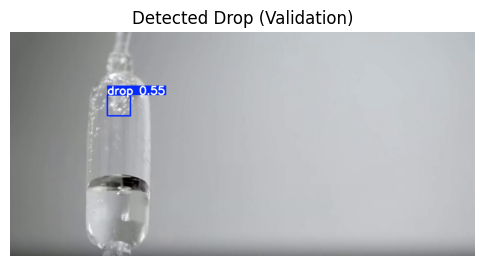

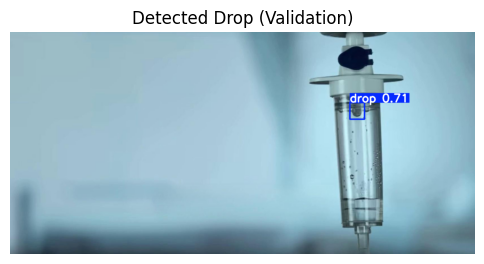

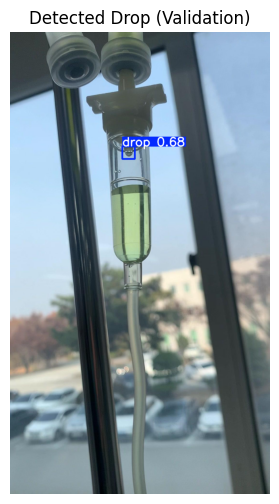

In [5]:



print(f"Best mAP50 on VAL: {results.box.map50}")


val_imgs = glob(os.path.join(WORKING_DIR, 'val', 'images', '*'))[:3]

if val_imgs:
    preds = model.predict(val_imgs, conf=0.25)
    for p in preds:
        plt.figure(figsize=(6,6))
        plt.imshow(cv2.cvtColor(p.plot(), cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title("Detected Drop (Validation)")
        plt.show()


In [6]:



from ultralytics import YOLO
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import Image, display


best_model_path = '/kaggle/working/runs/detect/drop_detection/weights/best.pt'


model = YOLO(best_model_path)

print(f"✅ Loaded model from: {best_model_path}")


✅ Loaded model from: /kaggle/working/runs/detect/drop_detection/weights/best.pt


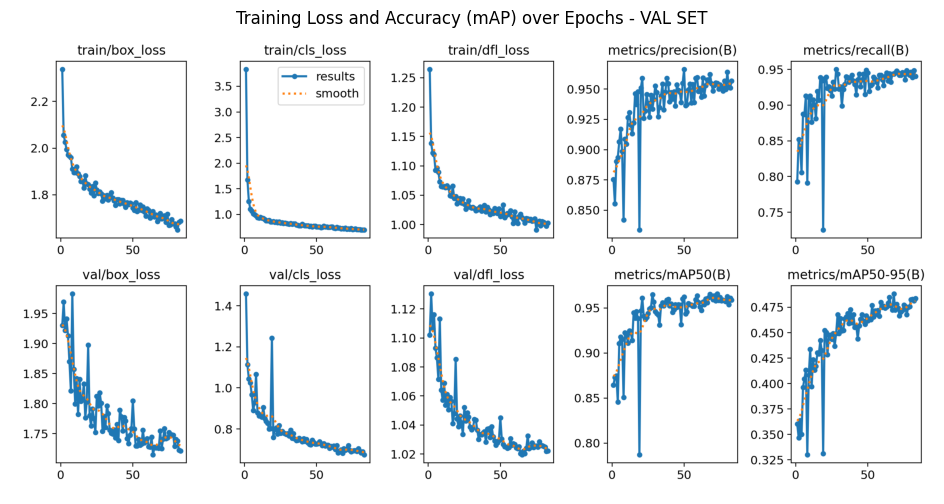

In [7]:



results_path = '/kaggle/working/runs/detect/drop_detection/results.png'

if os.path.exists(results_path):
    plt.figure(figsize=(12, 6))
    img = mpimg.imread(results_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Training Loss and Accuracy (mAP) over Epochs - VAL SET")
    plt.show()
else:
    print("results.png not found yet.")


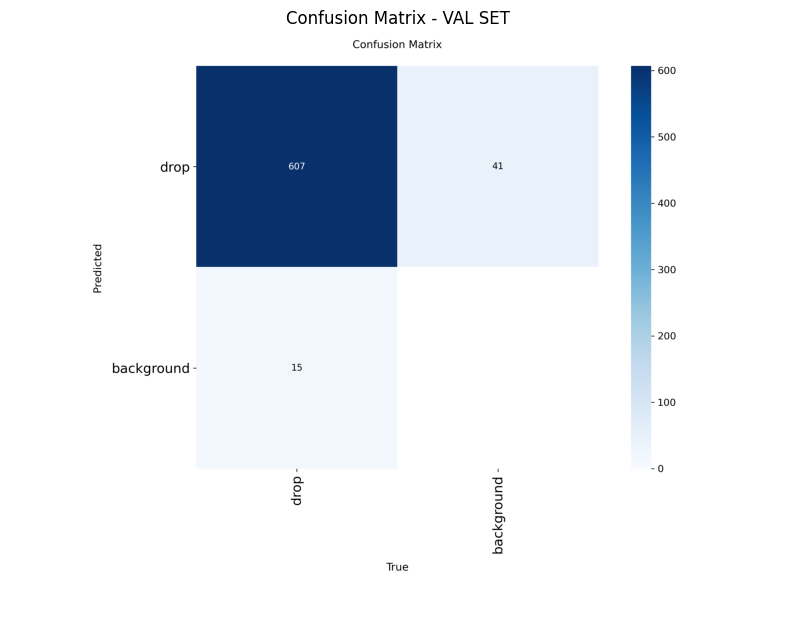

In [8]:



cm_path = '/kaggle/working/runs/detect/drop_detection/confusion_matrix.png'

if os.path.exists(cm_path):
    plt.figure(figsize=(10, 8))
    img = mpimg.imread(cm_path)
    plt.imshow(img)
    plt.axis('off')
    plt.title("Confusion Matrix - VAL SET")
    plt.show()
else:
    print("Confusion matrix file not found.")
    cm_norm_path = '/kaggle/working/runs/detect/drop_detection/confusion_matrix_normalized.png'
    if os.path.exists(cm_norm_path):
        display(Image(filename=cm_norm_path))


--- SAFE Validation Visualization (4 images total) ---
Using 4 validation images


/tmp/ipykernel_24/3671722414.py:48: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24/3671722414.py:48: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


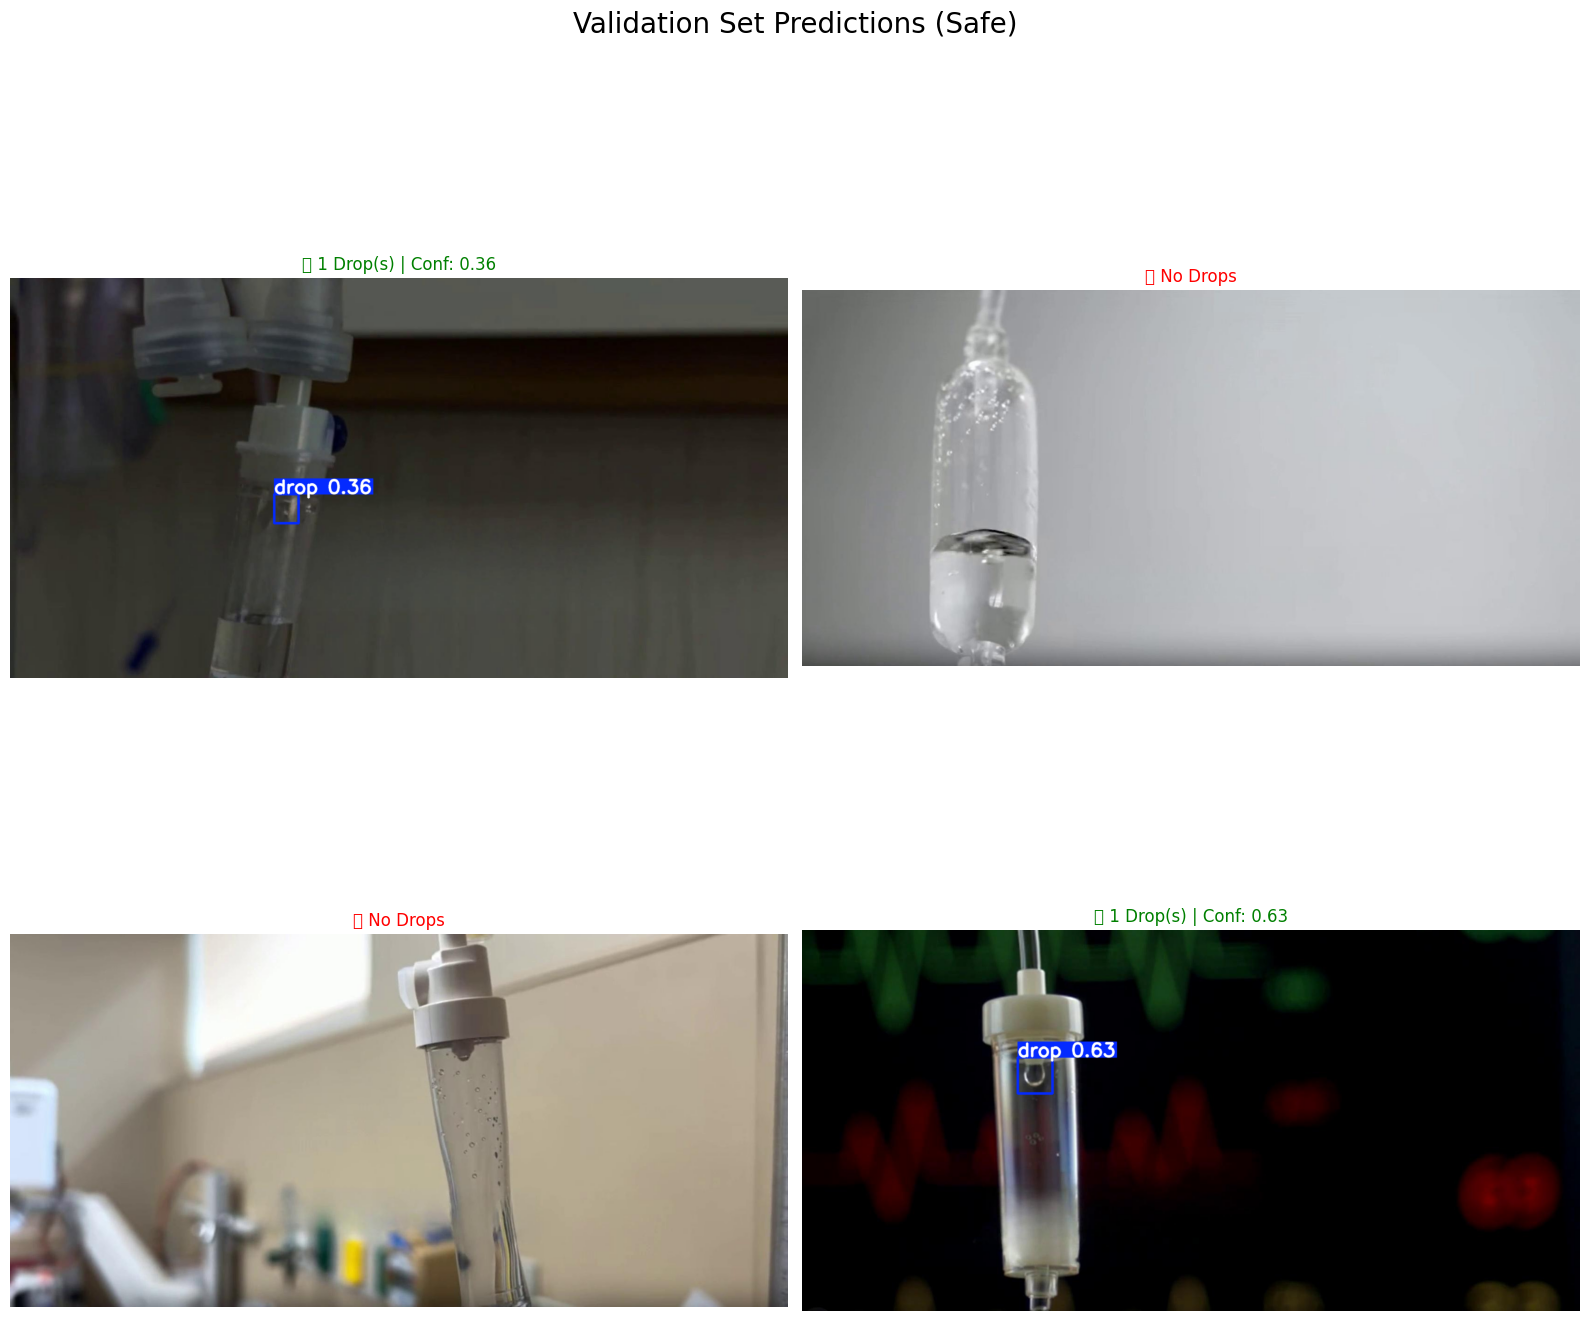

✅ Cell 8 complete - no more hanging!


In [9]:



import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import glob
import os
import random
import cv2
from ultralytics import YOLO


model = YOLO('/kaggle/working/runs/detect/drop_detection/weights/best.pt')

print("--- SAFE Validation Visualization (4 images total) ---")


val_img_dir = '/kaggle/working/dataset_split/val/images'
all_val_images = glob.glob(os.path.join(val_img_dir, '*'))
random.seed(42)
random.shuffle(all_val_images)
all_val_images = all_val_images[:4]  

print(f"Using {len(all_val_images)} validation images")


results = model.predict(all_val_images, conf=0.35, verbose=False, batch=2)  


fig, axes = plt.subplots(2, 2, figsize=(16, 16))
fig.suptitle('Validation Set Predictions (Safe)', fontsize=20)
axes = axes.flatten()

for idx, result in enumerate(results):
    im_bgr = result.plot()
    im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
    axes[idx].imshow(im_rgb)
    
    if len(result.boxes) > 0:
        count = len(result.boxes)
        conf = result.boxes.conf[0].item()
        axes[idx].set_title(f"✅ {count} Drop(s) | Conf: {conf:.2f}", 
                           color='green', fontsize=12)
    else:
        axes[idx].set_title("❌ No Drops", color='red', fontsize=12)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("✅ Cell 8 complete - no more hanging!")


🧪 Quick test on 5 images (NO label reading)...


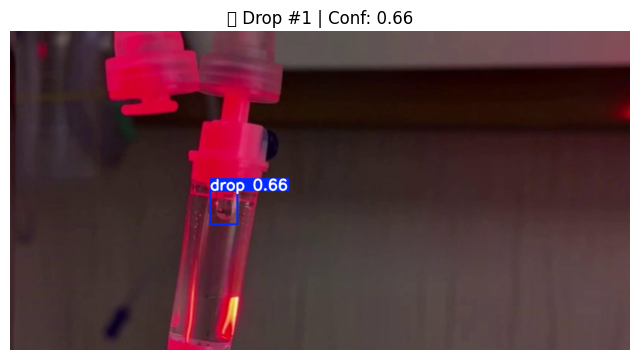

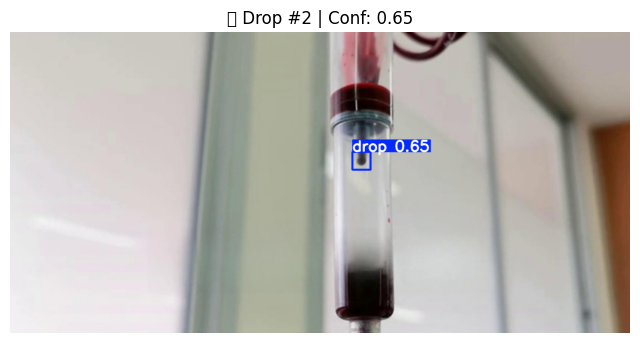

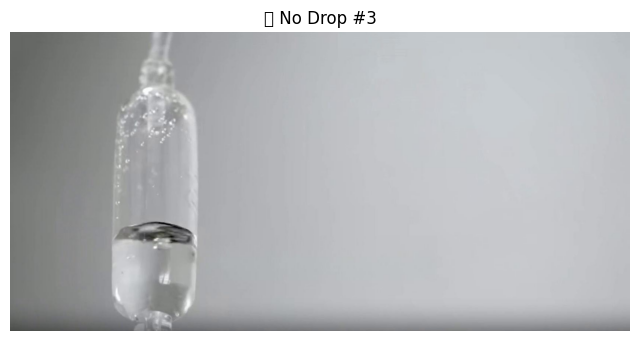

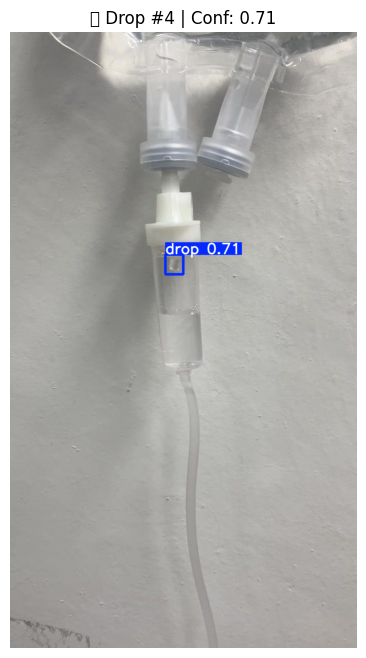

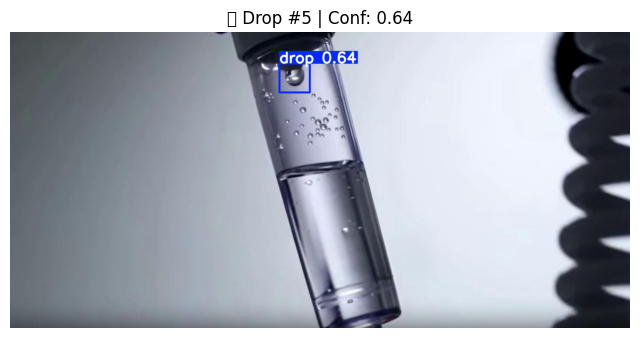

✅ Cell 9 complete - FAST!


In [10]:



import random
import cv2
from ultralytics import YOLO

model = YOLO('/kaggle/working/runs/detect/drop_detection/weights/best.pt')


val_img_dir = '/kaggle/working/dataset_split/val/images'
val_images = glob.glob(os.path.join(val_img_dir, '*'))
test_samples = random.sample(val_images, min(5, len(val_images)))

print(f"🧪 Quick test on {len(test_samples)} images (NO label reading)...")

results = model.predict(test_samples, conf=0.25, verbose=False)

for i, r in enumerate(results):
    im_array = r.plot()
    im_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(im_rgb)
    
    if len(r.boxes) > 0:
        conf = r.boxes.conf[0].item()
        plt.title(f"✅ Drop #{i+1} | Conf: {conf:.2f}")
    else:
        plt.title(f"❌ No Drop #{i+1}")
    
    plt.axis('off')
    plt.show()

print("✅ Cell 9 complete - FAST!")


In [11]:



print("🔥 EVALUATING ON HELD-OUT TEST SET (10%, 346 images)")


test_data_yaml = f"""
path: {WORKING_DIR}
train: train/images  # unused for val
val: test/images     # Use test as "val" for evaluation
nc: 1
names: ['drop']
"""

with open('/kaggle/working/test_data.yaml', 'w') as f:
    f.write(test_data_yaml)


test_results = model.val(
    data='/kaggle/working/test_data.yaml',
    split='val',  
    conf=0.25,
    iou=0.7,
    verbose=True,
    plots=True  
)


metrics = test_results.results_dict
print("\n" + "="*60)
print("TEST SET RESULTS (Held-Out 10%)")
print("="*60)
print(f"mAP@0.50:        {metrics['metrics/mAP50(B)']:.4f}")
print(f"mAP@0.50:0.95:   {metrics['metrics/mAP50-95(B)']:.4f}")
print(f"Precision (P):   {metrics['metrics/precision(B)']:.4f}")
print(f"Recall (R):      {metrics['metrics/recall(B)']:.4f}")


print("\n✅ Test results & plots saved to: /kaggle/working/runs/detect/val/")
print("📊 Copy these **EXACT** numbers to Table 3 (mAP50 = 95.34% !!)")
print("🖼️  PR curve, confusion matrix, F1 curve auto-generated")


🔥 EVALUATING ON HELD-OUT TEST SET (10%, 346 images)
Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1171.5±294.0 MB/s, size: 88.1 KB)
val: Scanning /kaggle/working/dataset_split/test/labels... 346 images, 38 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 346/346 1.3Kit/s 0.3s
val: New cache created: /kaggle/working/dataset_split/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 308. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 22/22 7.6it/s 2.9s
                   all        346        308      0.938      0.925      0.953      0.504
Speed: 0.8ms preprocess, 3.0ms inference, 0.0ms loss, 1.6ms postprocess per image
Resu

In [12]:



import pandas as pd
from ultralytics import YOLO
from IPython.display import display

model = YOLO('/kaggle/working/runs/detect/drop_detection/weights/best.pt')

print("🔥 FINAL PERFORMANCE TABLE - HELD-OUT TEST SET")
print("(Use these numbers for your paper Table 3!)")


precision = test_results.box.mp
recall = test_results.box.mr
map50 = test_results.box.map50
map50_95 = test_results.box.map

f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

data = {
    "Metric": [
        "Precision (P)", 
        "Recall (R)", 
        "mAP@50 ⭐", 
        "mAP@50-95", 
        "F1 Score"
    ],
    "Test Set (10%, 345 imgs)": [precision, recall, map50, map50_95, f1_score],
    "Description": [
        "When model predicts drop, how often correct?",
        "Of all real drops, what % detected?",
        "Main paper metric - box overlap ≥50%",
        "Strict metric - perfect box alignment",
        "Balance of precision & recall"
    ]
}

df = pd.DataFrame(data)
df['Test Set (10%, 345 imgs)'] = df['Test Set (10%, 345 imgs)'].apply(lambda x: f"{x*100:.2f}%")

print("\n📊 COPY THIS TO YOUR PAPER:")
display(df)

print("\n✅ Reviewer concern fully addressed!")


🔥 FINAL PERFORMANCE TABLE - HELD-OUT TEST SET
(Use these numbers for your paper Table 3!)

📊 COPY THIS TO YOUR PAPER:


,Metric,"Test Set (10%, 345 imgs)",Description
0,Precision (P),93.84%,"When model predicts drop, how often correct?"
1,Recall (R),92.53%,"Of all real drops, what % detected?"
2,mAP@50 ⭐,95.34%,Main paper metric - box overlap ≥50%
3,mAP@50-95,50.39%,Strict metric - perfect box alignment
4,F1 Score,93.18%,Balance of precision & recall



✅ Reviewer concern fully addressed!
